<a href="https://colab.research.google.com/github/Aayush974/learning-pytorch/blob/main/05_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer learning

Tranfer learning refers to taking the weights/patterns of an already trained model and using them for our own problem.

For example the food mini model we've build tries to recognize food items. We can use the patterns of some other working model, which was trained on the data which belongs to the same domain, to increase the efficiency of our own model

## why transfer learning?

transfer learning allows us to work with the patterns recognized by some other model which is proven to work on a similar problem to ours.

This prevents us from having to create a model from scratch which will be very time consuming and most likely perform worse than a well established model

The `torchvision.models` module contains commonly used pretrained models like ResNet, DenseNet, VGG etc

# Setup

## Getting the data

In [32]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists.


In [33]:
# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

## Importing the modular functions

let's make use of the functions we created in the previous notebook

In [34]:
try:
  from modular_functions import data_setup,engine
except:
  ! git clone https://github.com/Aayush974/learning-pytorch.git
  ! mv learning-pytorch/modular_functions .
  ! rm -rf learning-pytorch
  from modular_functions import data_setup,engine

In [35]:
modPath = Path(os.getcwd()) / "modular_functions"
for files,_,filenames in os.walk(modPath):
  print(filenames)

['data_setup.py', 'model_builder.py', 'engine.py', 'utils.py']
['data_setup.cpython-312.pyc', 'engine.cpython-312.pyc']


now we can import and use these functions whenever

# Creating Datasets and Dataloaders

when working with pre-trained models , it is important that our custom data given to the pre trained model, is similar to the input on which it was trained on, hence we will require the specific transforms for that

## manual transforms

prior to `torchvision` v0.13 , the transforms for models had to be created manually

It was required that alll pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224.

The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

following transforms demonstrate this:

In [36]:
import torchvision
from torchvision import transforms
# Create a transforms pipeline manually (required for torchvision < 0.13)
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])
manual_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [37]:
train_dataloaders,test_dataloader,classes = data_setup.create_dataloaders(
    train_dir,
    test_dir,
    manual_transforms,
    32
)
train_dataloaders,test_dataloader,classes

(<torch.utils.data.dataloader.DataLoader at 0x79ea5fea1f40>,
 ['pizza', 'steak', 'sushi'])

## automatic transforms

from `torchvision` v0.13+ onwards the transforms for a model can be created automatically
The [pytorch documentation](https://docs.pytorch.org/vision/main/models.html) states


> Before using the pre-trained models, one must preprocess the image (resize with right resolution/interpolation, apply inference transforms, rescale the values etc). There is no standard way to do this as it depends on how a given model was trained. It can vary across model families, variants or even weight versions. Using the correct preprocessing method is critical and failing to do so may lead to decreased accuracy or incorrect outputs.
All the necessary information for the inference transforms of each pre-trained model is provided on its weights documentation. To simplify inference, TorchVision bundles the necessary preprocessing transforms into each model weight. These are accessible via the weight.transforms attribute

```
weights = ResNet50_Weights.DEFAULT
preprocess_transforms = weights.transforms()
```

here
- ResNet50_Weights refers to the the weights of the ResNet50 architecture
- Default refers to the best available weights ( best performance on the ImageNet dataset). We can use other weight versions like `IMAGENET1K_V2` or `IMAGENET1K_V1`
- weights.transforms() gives access to the transforms which were used for that model architecture




In [38]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()
weights,auto_transforms

(EfficientNet_B0_Weights.IMAGENET1K_V1,
 ImageClassification(
     crop_size=[224]
     resize_size=[256]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BICUBIC
 ))

In [39]:
train_dataloaders,test_dataloader,class_names = data_setup.create_dataloaders(
    train_dir,
    test_dir,
    auto_transforms,
    32
)

# Getting the pre trained Model

we'll be using efficientNet_b0 model which is pre trained on ImageNet data so its quite suited for the image detection task of ours

In [40]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

as shown in the model output it has three layers

- features → Extracts visual patterns from the image such as edges, textures, shapes, and higher-level features.
- avgpool → Reduces and standardizes feature map dimensions by  averaging spatial information.
- classifier → Uses the extracted features to predict the final output class labels.

## Getting model summary with torchinfo

In [42]:
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

In [43]:
summary(
    model,
    input_size=(32,3,224,224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20
)

Layer (type:depth-idx)                                  Input Shape          Output Shape         Param #              Trainable
EfficientNet                                            [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential: 1-1                                       [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential: 2-2                                  [32, 32, 112, 112]   [32, 16, 112, 112]   --                   True
│    

well , well it seems like the number of params is stupidly larger than the no. of params in our TinyVgg model , ~8000 vs ~500000.
That is a LOT compared to anything we've build.

## Freezing the base model and modifying the output layers

to make use of the model we will "freeze" the base model which makes up the feature extraction part of the model.

This is important so that the weights learned by the model on whatever dataset it was trained on( in this case ImageNet) are not modified.

We only change the output layer shape to suit our model, currently the model oututs 1000 classes but we only need three (pizza,steak,sushi)

In [44]:
for param in model.features.parameters():
  param.requires_grad = False

the code above sets the requires_grad of all the parameters in the features layer to False

This means that pytorch will not track the gradients of these parameters hence they won't be changed by the optimizer during training


Now we have to modify the output layer to output the no. of classes we need.
As shown above in the model output, the classifier layer looks like

```
(classifier): Sequential(
    (0): Dropout(p=0.2, inplace=True)
    (1): Linear(in_features=1280, out_features=1000, bias=True)
  )
```

we'll keep the dropout layer as it as and change the out_features of Linear layer to 3



> **Dropout layer** randomly deactives a fraction of the neuron during training the reduce overfitting. The number of fractions deactivated is decided by `p` so if `p=0.2` then 20% of neurons will be dropped randomly during each pass





In [45]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(classes)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2,inplace=True),
    torch.nn.Linear(in_features=1280,out_features=output_shape)
).to(device)

let's get another summary of the modified model

In [46]:
summary(
    model,
    input_size=(32,3,224,224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20
)

Layer (type:depth-idx)                                  Input Shape          Output Shape         Param #              Trainable
EfficientNet                                            [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential: 2-2                                  [32, 32, 112, 112]   [32, 16, 112, 112]   --                   Fal

the params of the features layers now show false for learnable and the classifier output is just 3 classes.
This is what we wanted

# Training the Model

now its time to train and see how the pre trained model performed

In [47]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [48]:
from timeit import default_timer as timer

start_time = timer()

results = engine.train(
    model,
    train_dataloaders,
    test_dataloader,
    optimizer,
    loss_fn,
    5,
    device
)

end_time = timer()

print(f"the pretrained model took {end_time-start_time} seconds to complete")

Epoch: 1 | train_loss: 1.0464 | train_acc: 38.6719 | test_loss: 0.8375 | test_acc: 73.3902
Epoch: 2 | train_loss: 0.9120 | train_acc: 63.2812 | test_loss: 0.7124 | test_acc: 88.6364
Epoch: 3 | train_loss: 0.7645 | train_acc: 74.2188 | test_loss: 0.6899 | test_acc: 87.5947
Epoch: 4 | train_loss: 0.7190 | train_acc: 73.8281 | test_loss: 0.6011 | test_acc: 85.5114
Epoch: 5 | train_loss: 0.6177 | train_acc: 78.5156 | test_loss: 0.5983 | test_acc: 85.6061
the pretrained model took 12.031217428999753 seconds to complete


well well it seems like the pre trained performed quite well compared to our previous tiny VGG model

## plotting the loss curves

let's plot the loss curves

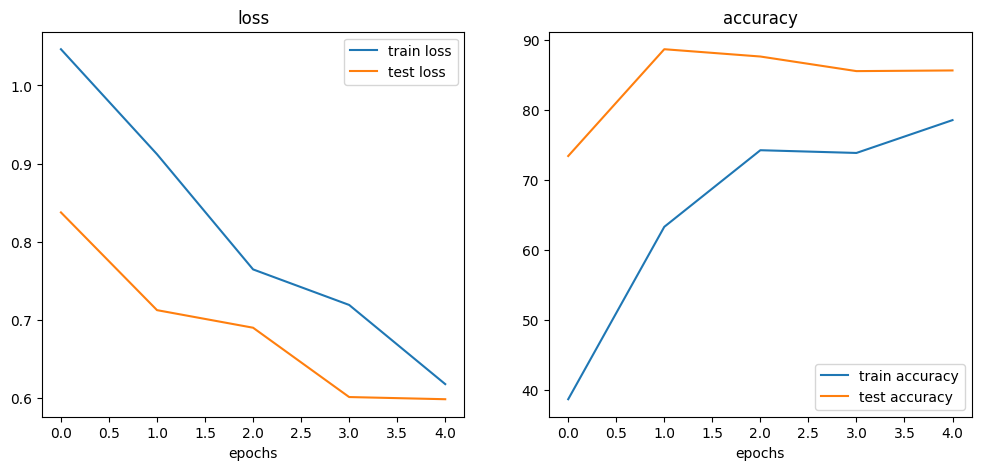

In [49]:
from matplotlib import pyplot as plt
from typing import Dict
def plot_losscurve(
    restults:Dict
):
  loss = results["train_loss"]
  acc = results["train_acc"]
  test_loss = results["test_loss"]
  test_acc = results["test_acc"]

  epochs = range(len(loss))

  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train loss")
  plt.plot(epochs,test_loss,label="test loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs,acc,label ="train accuracy")
  plt.plot(epochs,test_acc, label = "test accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()


plot_losscurve(results)

yup these loss curves look significantly better than previous model's chaotic loss curves

# Predicting the image

to predict a raw image it must be made sure that the image has

- same shape
- same datatype
- same device
- same transformation

as the image that the model was trained on

In [50]:
from PIL import Image
from typing import List,Tuple

def pred_and_plot(
    model: torch.nn.Module,
    image_path:str,
    class_names:List[str],
    image_size:Tuple[int,int]=(224,224),
    transform: torchvision.transforms = None,
    device:torch.device = device
):
  img = Image.open(image_path)

  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(size=(224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
    ])

  model.to(device)
  model.eval()

  with torch.inference_mode():
    transformed_img = image_transform(img).unsqueeze(dim=0)
    img_pred = model(transformed_img.to(device))
    img_pred_probs = torch.softmax(img_pred,dim=1)
    img_pred_label = torch.argmax(img_pred_probs,dim=1)


  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[img_pred_label]} | Prob: {img_pred_probs.max():.3f}")
  plt.axis(False)

## predicting image from test set

getting 3 random images from test directory

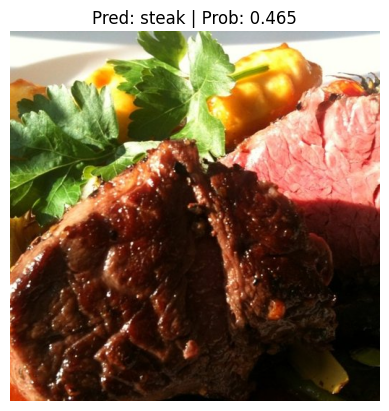

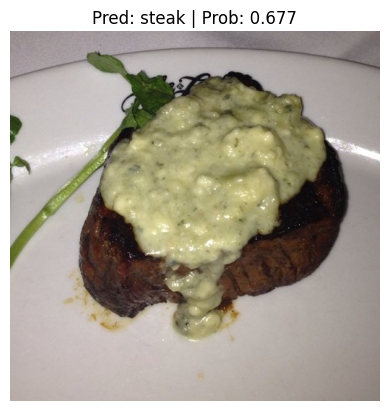

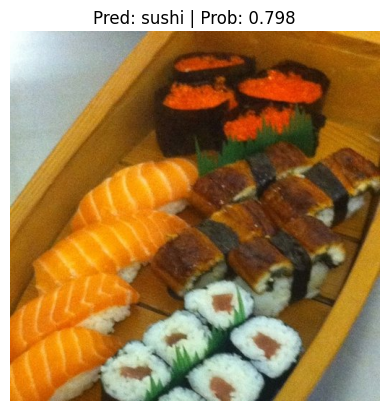

In [55]:
import random

num_imgs = 3
image_list = list(Path(test_dir).glob("*/*.jpg"))
image_sample = random.sample(
    population=image_list,
    k=num_imgs
)

for image_path in image_sample:
  pred_and_plot(
      model,
      image_path,
      class_names
  )

## predicting a custom image

getting a custom image from the tutorial

data/04-pizza-dad.jpeg already exists, skipping download.


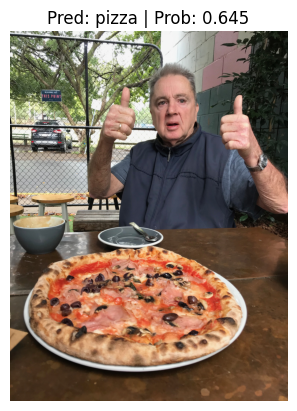

In [53]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)